### Task 1
#### Layyana Junaid 23k0056

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [7]:
data_normal = 'Data/NORMAL'
print(os.listdir(data_normal)[:10])

['NORMAL.png', 'NORMAL_10.png', 'NORMAL_100.png', 'NORMAL_1000.png', 'NORMAL_1001.png', 'NORMAL_1002.png', 'NORMAL_1003.png', 'NORMAL_1004.png', 'NORMAL_1005.png', 'NORMAL_1006.png']


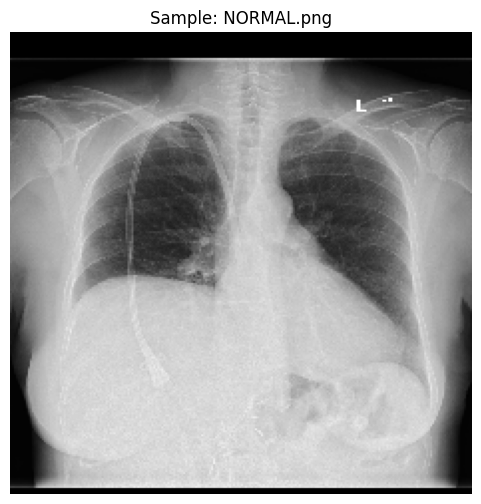

In [8]:
sample_filename = os.listdir(data_normal)[0]
sample_path = os.path.join(data_normal, sample_filename)

img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"cv2 couldn't read: {sample_path}")

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title(f'Sample: {sample_filename}')
plt.axis('off')
plt.show()

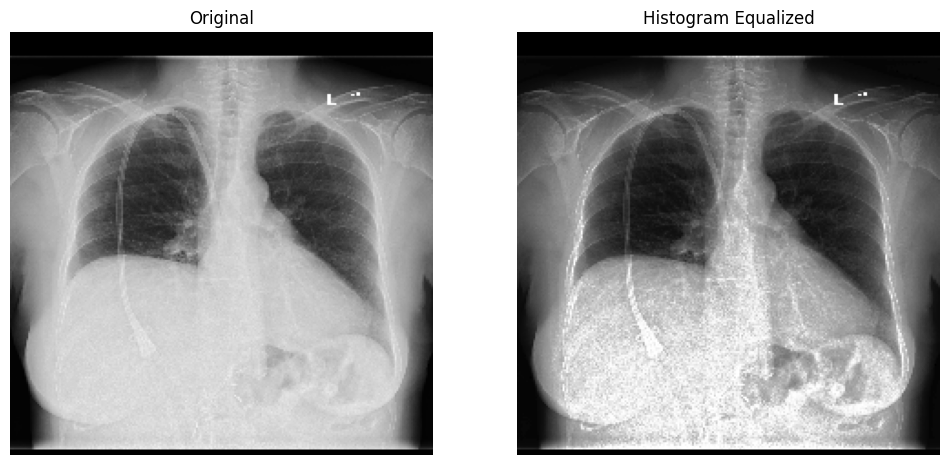

In [9]:
equalized = cv2.equalizeHist(img)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(equalized, cmap='gray')
axes[1].set_title('Histogram Equalized')
axes[1].axis('off')
plt.show()

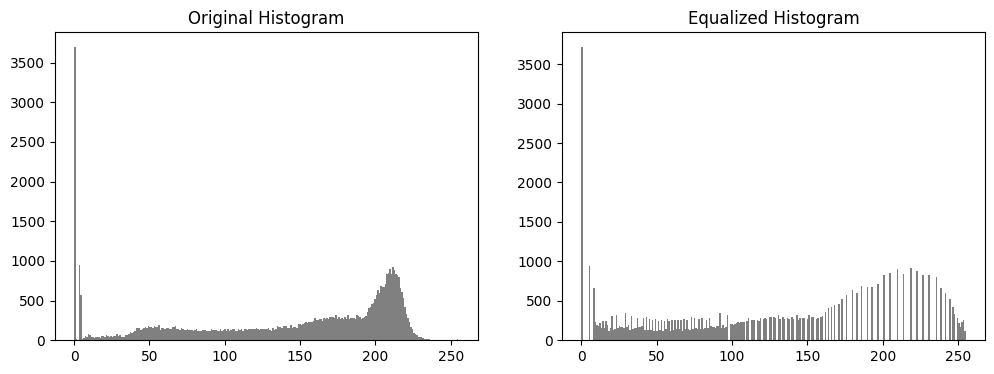

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(img.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original Histogram')

axes[1].hist(equalized.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title('Equalized Histogram')
plt.show()

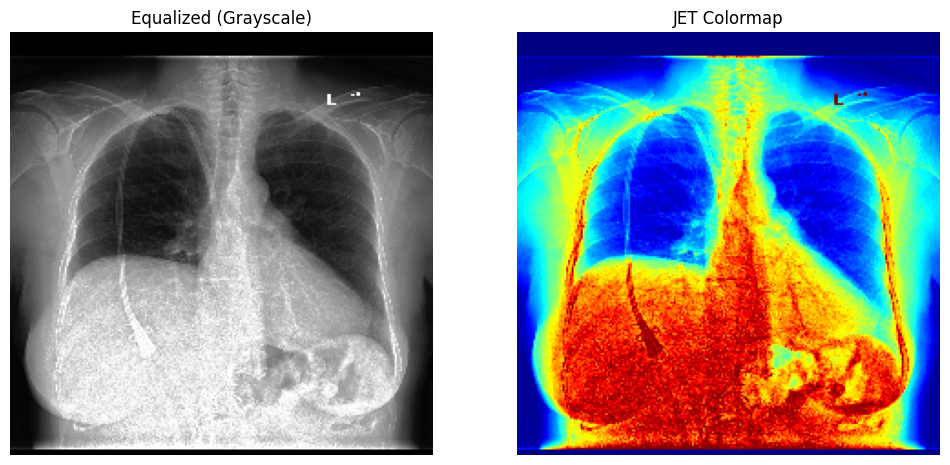

In [11]:
heatmap = cv2.applyColorMap(equalized, cv2.COLORMAP_JET)

heatmap_rgb = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(equalized, cmap='gray')
axes[0].set_title('Equalized (Grayscale)')
axes[0].axis('off')

axes[1].imshow(heatmap_rgb)
axes[1].set_title('JET Colormap')
axes[1].axis('off')
plt.show()

Technically the coloured heatmap is helping us identify skin and not skin more properly

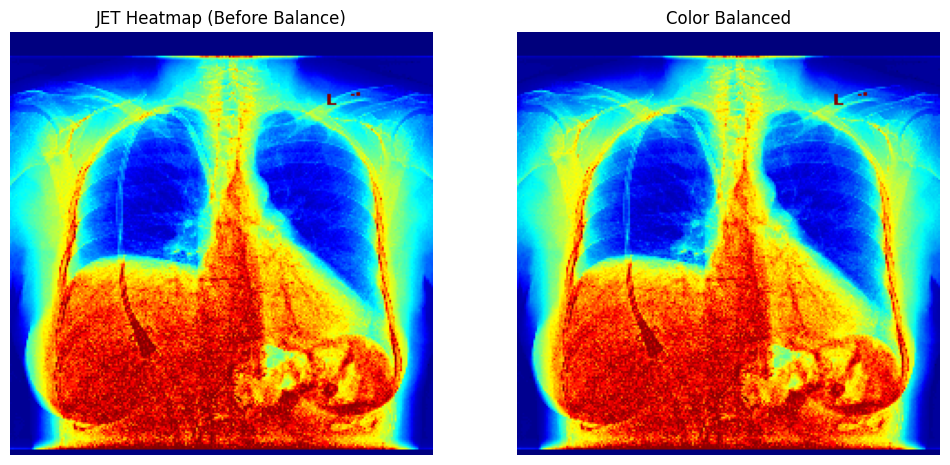

In [12]:
def gray_world_balance(img_bgr):
    img_float = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img_float)
    
    b_mean, g_mean, r_mean = b.mean(), g.mean(), r.mean()
    gray_mean = (b_mean + g_mean + r_mean) / 3
    
    b = b * (gray_mean / b_mean)
    g = g * (gray_mean / g_mean)
    r = r * (gray_mean / r_mean)
    
    balanced = cv2.merge([b, g, r])
    balanced = np.clip(balanced, 0, 255).astype(np.uint8)
    return balanced

import numpy as np
balanced = gray_world_balance(heatmap)
balanced_rgb = cv2.cvtColor(balanced, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(heatmap_rgb)
axes[0].set_title('JET Heatmap (Before Balance)')
axes[0].axis('off')

axes[1].imshow(balanced_rgb)
axes[1].set_title('Color Balanced')
axes[1].axis('off')
plt.show()

In [13]:
b, g, r = cv2.split(heatmap.astype(np.float32))
print("Before balance — B: %.2f, G: %.2f, R: %.2f" % (b.mean(), g.mean(), r.mean()))

b2, g2, r2 = cv2.split(balanced.astype(np.float32))
print("After balance  — B: %.2f, G: %.2f, R: %.2f" % (b2.mean(), g2.mean(), r2.mean()))

Before balance — B: 119.91, G: 117.06, R: 111.53
After balance  — B: 115.99, G: 115.93, R: 113.42


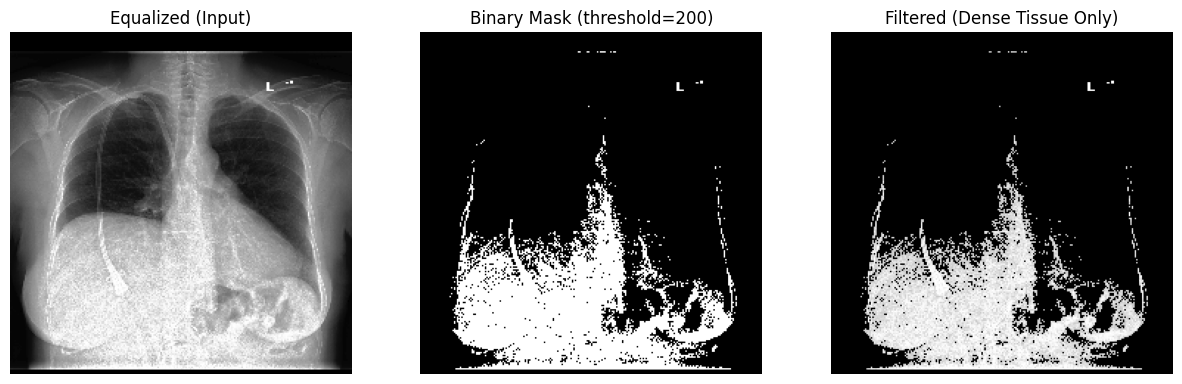

In [14]:
threshold_value = 200  

_, mask = cv2.threshold(equalized, threshold_value, 255, cv2.THRESH_BINARY)

filtered = cv2.bitwise_and(equalized, equalized, mask=mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(equalized, cmap='gray')
axes[0].set_title('Equalized (Input)')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'Binary Mask (threshold={threshold_value})')
axes[1].axis('off')

axes[2].imshow(filtered, cmap='gray')
axes[2].set_title('Filtered (Dense Tissue Only)')
axes[2].axis('off')
plt.show()

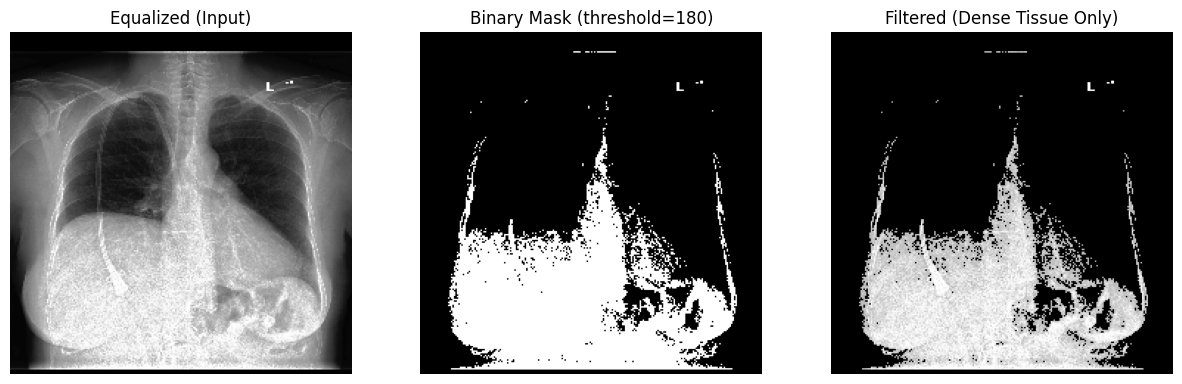

In [15]:
threshold_value = 180

_, mask = cv2.threshold(equalized, threshold_value, 255, cv2.THRESH_BINARY)

filtered = cv2.bitwise_and(equalized, equalized, mask=mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(equalized, cmap='gray')
axes[0].set_title('Equalized (Input)')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f'Binary Mask (threshold={threshold_value})')
axes[1].axis('off')

axes[2].imshow(filtered, cmap='gray')
axes[2].set_title('Filtered (Dense Tissue Only)')
axes[2].axis('off')
plt.show()

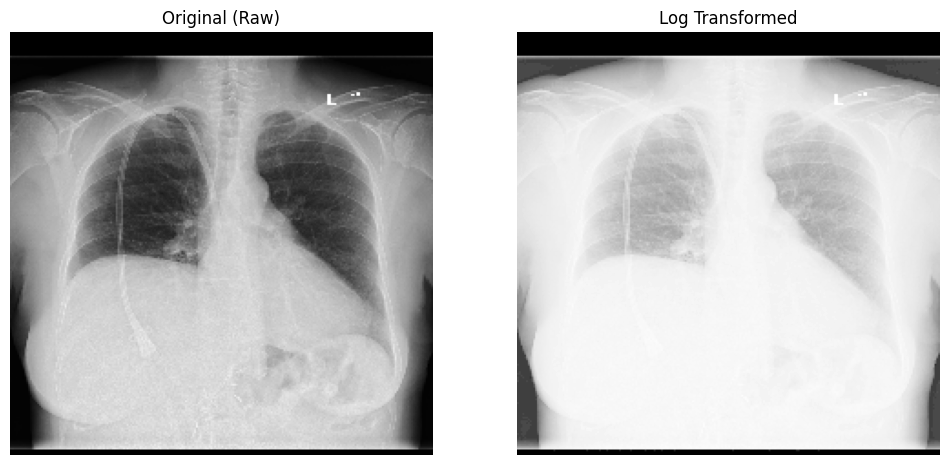

In [16]:
img_float = img.astype(np.float32)

c = 255 / np.log(1 + np.max(img_float))
log_transformed = c * np.log(1 + img_float)
log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (Raw)')
axes[0].axis('off')

axes[1].imshow(log_transformed, cmap='gray')
axes[1].set_title('Log Transformed')
axes[1].axis('off')
plt.show()

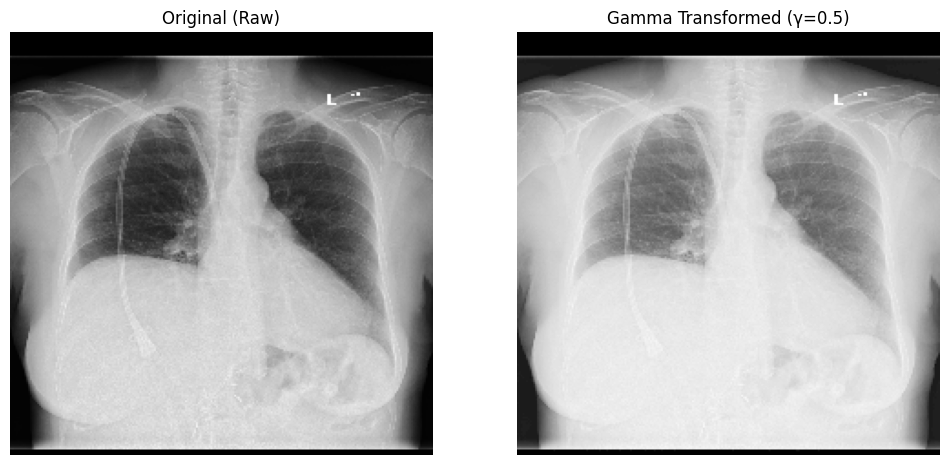

In [17]:
gamma = 0.5  

img_norm = img.astype(np.float32) / 255.0          
gamma_transformed = np.power(img_norm, gamma)       
gamma_transformed = (gamma_transformed * 255).clip(0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (Raw)')
axes[0].axis('off')

axes[1].imshow(gamma_transformed, cmap='gray')
axes[1].set_title(f'Gamma Transformed (γ={gamma})')
axes[1].axis('off')
plt.show()